<h2 style="
color:#e6a8c9;
font-weight:650;
letter-spacing:0.01em;
">
Annexe I  Mécanisme géométrique de Hardt
</h2>


<p>
Cette annexe détaille le mécanisme géométrique qui permet à la méthode de Hardt d’utiliser une randomisation entre plusieurs seuils.

<p>
Le modèle produit d’abord un score de risque :
</p>

<div style="
text-align:center;
font-size:1.08em;
margin:1.4em 0 1.8em 0;
">

$$
s(x)=P(Y=1\mid X=x)
$$

</div>

<p>
Pour transformer ce score en décision binaire, on applique un seuil :
</p>

<div style="
text-align:center;
font-size:1.08em;
margin:1.4em 0 2em 0;
">

$$
\hat Y = 1
\quad \text{si} \quad
s(x)\geq \tau
$$

</div>

<div style="
margin:1.2em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.9;
">

<b>Seuil déterministe</b>

Un seuil est dit <b>déterministe</b> car une même valeur de score conduit toujours à une même décision.

Lorsque l’on fait varier $\tau$, on obtient différents couples :

$$
(FPR(\tau),\;TPR(\tau))
$$

Chaque seuil déterministe correspond donc à un point précis sur la courbe ROC du groupe.

</div>

<br>

<div style="
margin-top:1.2em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

<b>Limitation sur données finies</b>

La ROC empirique n’est pas continue :
elle est composée d’un nombre limité de points atteignables par des seuils fixes.

Il peut donc arriver qu’aucun seuil déterministe ne permette d’obtenir exactement le niveau de TPR souhaité pour satisfaire :

$$
TPR_{jeunes}\approx TPR_{adultes}
$$

</div>

<div style="
margin:2em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.9;
">

<b>Exemple</b>

Deux seuils voisins peuvent produire :

$$
(TPR,FPR)_1=(0.44,\;0.12)
$$

et :

$$
(TPR,FPR)_2=(0.51,\;0.18)
$$

sans qu’aucun seuil fixe ne permette d’atteindre exactement :

$$
(0.47,\;0.15)
$$

</div>

<hr style="
margin:3em 0;
border:none;
border-top:1px solid rgba(255,255,255,0.10);
">

<div style="
margin:1.3em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

<b>Idée centrale de Hardt</b>

La méthode contourne cette limitation en randomisant entre deux seuils.

Par exemple :

$$
\begin{aligned}
82\% &: \quad s(x)>0.829 \\
18\% &: \quad s(x)>0.757
\end{aligned}
$$

L’algorithme applique donc parfois un seuil, parfois l’autre.

</div>

<div style="
text-align:center;
margin:2.4em 0 2.2em 0;
">

<div style="
font-size:0.74em;
letter-spacing:0.12em;
text-transform:uppercase;
opacity:0.55;
margin-bottom:0.8em;
">

Effet moyen obtenu

</div>

$$
\begin{aligned}
TPR &= 0.82\times TPR_1 + 0.18\times TPR_2 \\
\\
FPR &= 0.82\times FPR_1 + 0.18\times FPR_2
\end{aligned}
$$

</div>

<p>
Le point obtenu se situe alors exactement sur le segment reliant les deux points ROC initiaux.
</p>

<div style="
margin-top:1.3em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

<b>Enveloppe convexe</b>

La randomisation permet ainsi d’atteindre tous les points intermédiaires entre les seuils déterministes.

<ul style="margin-top:0.8em;">
<li>
les seuils fixes donnent les points de la ROC ;
</li>

<li style="margin-top:0.45em;">
la randomisation construit ensuite les segments reliant ces points.
</li>
</ul>

L’espace des solutions accessibles devient alors beaucoup plus large que la seule ROC empirique.

</div>

<div style="
margin-top:1.8em;
padding-top:0.9em;
border-top:1px solid rgba(255,255,255,0.12);
font-size:1.02em;
line-height:1.95;
">

<b>Point important.</b>

La méthode de Hardt n’optimise donc pas uniquement sur des seuils fixes,
mais sur cette enveloppe convexe élargie par randomisation.

Sans cette extension, atteindre exactement une contrainte fairness est souvent impossible sur données finies.

Avec elle, l’algorithme peut satisfaire beaucoup plus précisément l’Equal Opportunity.

</div>

<div style="
margin-top:1.6em;
padding:0.95em 1.15em;
background:rgba(255,255,255,0.03);
border-left:3px solid #8d6cab;
border-radius:6px;
line-height:1.9;
font-size:0.98em;
">

<b>Conséquence importante.</b>

Cette correction agit au niveau des groupes et non des individus :

<i>
deux individus très similaires peuvent recevoir des décisions différentes afin de satisfaire une contrainte statistique globale.
</i>

</div>

In [10]:
import numpy as np
import matplotlib.pyplot as plt                                                                                                    
from sklearn.metrics import roc_curve, roc_auc_score  

In [11]:
data = np.load("hardt_annex_data.npz")
p_nat = data["p_nat"]   # P(Y=1 | x) sur le test, baseline LR
y_te  = data["y_te"]    # labels vrais (0=bad, 1=good)                                                                             
A_te  = data["A_te"]    # attribut sensible (1=jeune <25, 0=adulte)                                                                
                                                                                                                                    
print(f"n_test = {len(y_te)}  |  % jeunes = {A_te.mean():.1%}  |  % good = {y_te.mean():.1%}")      

n_test = 300  |  % jeunes = 14.7%  |  % good = 70.0%


In [15]:
def upper_convex_hull_roc(fpr, tpr):
    """Upper convex hull d'une ROC empirique, complétée par (0,0) et (1,1)."""                                                     
    pts = sorted(set([(0.0, 0.0)] + list(zip(fpr, tpr)) + [(1.0, 1.0)]))
    upper = []                                                                                                                     
    for p in pts:                                                                                                                
        while len(upper) >= 2:                                                                                                     
            o, a = upper[-2], upper[-1]                                                                                            
            cross = (a[0] - o[0]) * (p[1] - o[1]) - (a[1] - o[1]) * (p[0] - o[0])
            if cross >= 0:   # hull supérieur (parcouru G→D) : pop si a sous/colinéaire à op                                       
                upper.pop()                                                                                                        
            else:                                                                                                                  
                break                                                                                                              
        upper.append(p)                                                                                                          
    return np.array(upper)         

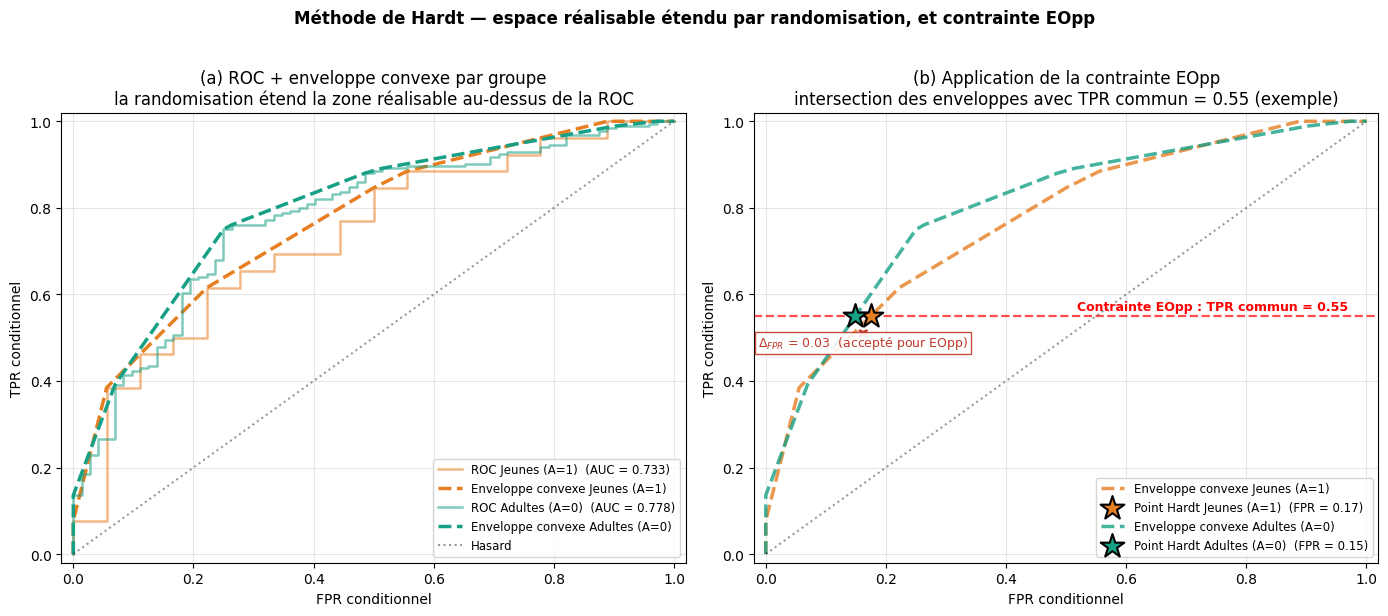

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))                                                                                    
ax = axes[0]                                                                                                                       
for a, color, lbl in [(1, "#E67E22", "Jeunes (A=1)"), (0, "#16A085", "Adultes (A=0)")]:                                            
    m = A_te == a                                                                                                                  
    f, t, _ = roc_curve(y_te[m], p_nat[m])                                                                                         
    hull = upper_convex_hull_roc(f, t)                                                                                             
    ax.plot(f, t, color=color, lw=1.8, alpha=0.55,                                                                                 
            label=f"ROC {lbl}  (AUC = {roc_auc_score(y_te[m], p_nat[m]):.3f})")
    ax.plot(hull[:, 0], hull[:, 1], color=color, ls="--", lw=2.5, alpha=1.0,                                                       
            label=f"Enveloppe convexe {lbl}")                                                                                      
ax.plot([0, 1], [0, 1], "k:", alpha=0.4, label="Hasard")                                                                           
ax.set_xlabel("FPR conditionnel")                                                                                                  
ax.set_ylabel("TPR conditionnel")                                                                                                
ax.set_title("(a) ROC + enveloppe convexe par groupe\nla randomisation étend la zone réalisable au-dessus de la ROC")              
ax.legend(loc="lower right", fontsize=8.5)                                                                                       
ax.grid(alpha=0.3)                                                                                                                 
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)                                                                               
                                                                                                                                    
# ============ Panel (b) : contrainte EOpp + points opérationnels ============                                                   
ax = axes[1]                                                                                                                       
t_star_illust = 0.55   # exemple pédagogique (TPR commun choisi pour illustrer)                                                  
                                                                                                                                    
ops = {}
for a, color, lbl in [(1, "#E67E22", "Jeunes (A=1)"), (0, "#16A085", "Adultes (A=0)")]:                                            
    m = A_te == a                                                                                                                  
    f, t, _ = roc_curve(y_te[m], p_nat[m])
    hull = upper_convex_hull_roc(f, t)                                                                                             
    ax.plot(hull[:, 0], hull[:, 1], color=color, ls="--", lw=2.5, alpha=0.8,                                                     
            label=f"Enveloppe convexe {lbl}")                                                                                      
    # FPR sur l'enveloppe au niveau t_star_illust (interpolation)                                                                
    fpr_at = float(np.interp(t_star_illust, hull[:, 1], hull[:, 0]))                                                               
    ops[a] = (fpr_at, t_star_illust)                                                                                             
    ax.scatter(fpr_at, t_star_illust, s=320, marker="*", color=color,                                                              
                edgecolor="black", linewidth=1.5, zorder=5,                                                                         
                label=f"Point Hardt {lbl}  (FPR = {fpr_at:.2f})")                                                                   
                                                                                                                                    
# Ligne horizontale de la contrainte EOpp                                                                                        
ax.axhline(t_star_illust, color="red", ls="--", lw=1.6, alpha=0.7)                                                                 
ax.text(0.97, t_star_illust + 0.015, f"Contrainte EOpp : TPR commun = {t_star_illust}",                                            
        ha="right", color="red", fontsize=9, fontweight="bold")                                                                    
                                                                                                                                    
# Visualiser que les FPR diffèrent : segment horizontal entre les deux points                                                      
fpr_low, fpr_high = sorted([ops[0][0], ops[1][0]])                                                                               
ax.annotate("", xy=(fpr_low, t_star_illust - 0.04),                                                                                
            xytext=(fpr_high, t_star_illust - 0.04),                                                                             
            arrowprops=dict(arrowstyle="<->", color="#C0392B", lw=1.8))                                                            
ax.text((fpr_low + fpr_high) / 2, t_star_illust - 0.07,                                                                          
        f"$\\Delta_{{FPR}}$ = {fpr_high - fpr_low:.2f}  (accepté pour EOpp)",                                                      
        ha="center", color="#C0392B", fontsize=9,                                                                                  
        bbox=dict(facecolor="white", edgecolor="#C0392B", alpha=0.9, pad=2))                                                       
                                                                                                                                    
ax.plot([0, 1], [0, 1], "k:", alpha=0.4)                                                                                         
ax.set_xlabel("FPR conditionnel")                                                                                                  
ax.set_ylabel("TPR conditionnel")                                                                                                  
ax.set_title(f"(b) Application de la contrainte EOpp\nintersection des enveloppes avec TPR commun = {t_star_illust} (exemple)")
ax.legend(loc="lower right", fontsize=8.5)                                                                                         
ax.grid(alpha=0.3)                                                                                                               
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)                                                                                 
                                                                                                                                    
plt.suptitle("Méthode de Hardt — espace réalisable étendu par randomisation, et contrainte EOpp",                                  
            fontweight="bold", y=1.02)                                                                                            
plt.tight_layout()                                                                                                                 
plt.show()     

<h3>Lecture de la figure</h3>

<div style="
margin:1.3em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

<b>Panneau (a)</b>

Le panneau (a) illustre directement le mécanisme décrit précédemment.

<ul style="margin-top:0.8em;">
<li>
les courbes pleines correspondent aux seuils déterministes
</li>

<li style="margin-top:0.45em;">
les segments pointillés représentent les points supplémentaires accessibles par randomisation.
</li>
</ul>

La méthode n’optimise donc plus uniquement sur la ROC empirique, mais sur son enveloppe convexe.

</div>

<hr style="
margin:2.8em 0;
border:none;
border-top:1px solid rgba(255,255,255,0.10);
">

<div style="
margin:1.3em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.95;
">

<b>Panneau (b)</b><br><br>

Le panneau (b) montre comment cette extension permet ensuite de satisfaire une contrainte d’Equal Opportunity.

<br><br>

La ligne horizontale impose ici un :

<div style="
text-align:center;
font-size:1.04em;
margin:1.2em 0 1em 0;
">

$$
TPR \text{ commun}
$$

</div>

Les étoiles représentent alors les solutions sélectionnées sur les enveloppes convexes des deux groupes.

</div>

<div style="
margin-top:1.5em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

La randomisation permet ainsi d’atteindre des points intermédiaires qui ne seraient pas accessibles avec des seuils fixes uniquement.

</div>